<a href="https://colab.research.google.com/github/salonapaliwal7/Machine-Learning-Projects/blob/main/Fashion_MNIST_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [22]:
x_train.shape

(60000, 28, 28)

In [23]:
x_test.shape

(10000, 28, 28)

In [24]:
import numpy as np

# expand dimension to include channel dimensions as well
x_train = np.expand_dims(x_train, axis=-1)  # 28 x 28 x 1
x_test = np.expand_dims(x_test, axis=-1)
x_train.shape

(60000, 28, 28, 1)

In [25]:
# normalize

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0


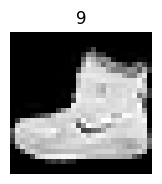

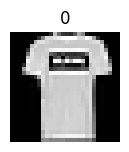

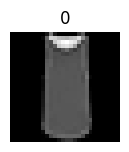

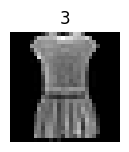

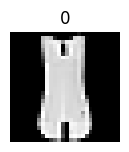

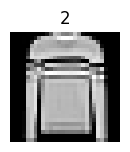

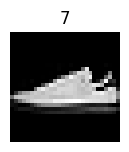

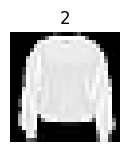

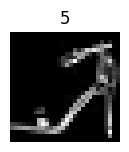

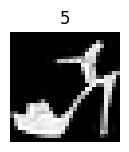

In [26]:
# plot image

import matplotlib.pyplot as plt


plt.figure(figsize=(8,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i], cmap="gray")
  plt.title(y_train[i])
  plt.axis("off")
  plt.tight_layout()
  plt.show()

In [27]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
Conv2D,
MaxPooling2D,
Flatten,
Dense,
Input,
Dropout,
GlobalAveragePooling2D
)


model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(
        filters = 32,
        kernel_size = (3,3),
        padding = "same",
        activation = 'relu'
    ),
    Conv2D(
        filters = 32,
        kernel_size = (3,3),
        padding = "same",
        activation = 'relu'
    ),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(
        filters = 64,
        kernel_size = (3,3),
        padding = "same",
        activation = 'relu'
    ),
    Conv2D(
        filters = 64,
        kernel_size = (3,3),
        padding = "same",
        activation = 'relu'
    ),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(
        filters = 128,
        kernel_size = (3,3),
        padding = "same",
        activation = 'relu'
    ),
    MaxPooling2D(pool_size=(2,2)),
    GlobalAveragePooling2D(),
    Dense(128, activation = "relu"),
    Dropout(0.5),
    Dense(10, activation = "softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,650 (611.91 KB)

 Trainable params: 156,650 (611.91 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# apply early stopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model.compile(
              optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy'],
              )
history = model.fit(x_train, y_train, validation_split=0.1, epochs=15, batch_size=128, callbacks=[early_stop] )

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6686 - loss: 0.8890 - val_accuracy: 0.8093 - val_loss: 0.5080
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8123 - loss: 0.5159 - val_accuracy: 0.8473 - val_loss: 0.4159
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8468 - loss: 0.4280 - val_accuracy: 0.8698 - val_loss: 0.3443
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8689 - loss: 0.3662 - val_accuracy: 0.8857 - val_loss: 0.3077
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8820 - loss: 0.3308 - val_accuracy: 0.8895 - val_loss: 0.3082
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8925 - loss: 0.3020 - val_accuracy: 0.9038 - val_loss: 0.2669
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9003 - loss: 0.2808 - val_accuracy: 0.9030 - val_loss: 0.2654
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9055 - loss: 0.2624 - val_accur

In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9207 - loss: 0.2225


In [30]:
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9207000136375427


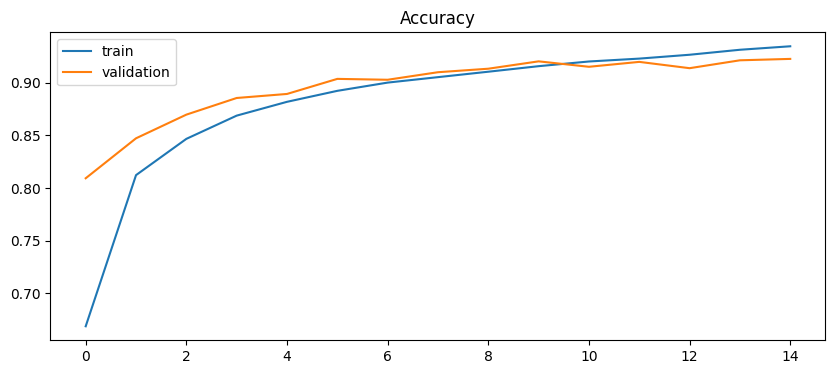

In [31]:
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.legend()
plt.title("Accuracy")
plt.show()

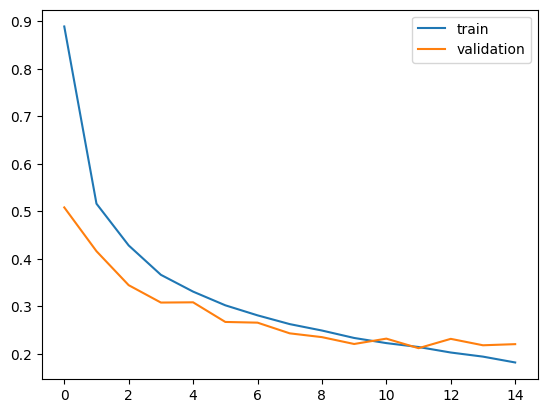

In [32]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.legend()
plt.show()

In [33]:
 predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


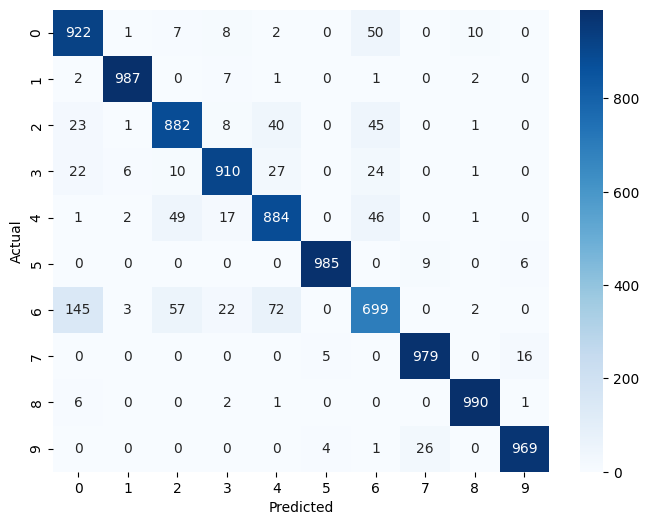

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predicted_labels
))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1000
           1       0.99      0.99      0.99      1000
           2       0.88      0.88      0.88      1000
           3       0.93      0.91      0.92      1000
           4       0.86      0.88      0.87      1000
           5       0.99      0.98      0.99      1000
           6       0.81      0.70      0.75      1000
           7       0.97      0.98      0.97      1000
           8       0.98      0.99      0.99      1000
           9       0.98      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

